In [1]:
import pandas as pd

df_raw = pd.read_parquet("../data/yellow_tripdata_2026-01.parquet")

print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())
df_raw.head()

Shape: (3724889, 20)

Columns:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [2]:
for col in df_raw.columns.tolist():
    print(col)

VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
cbd_congestion_fee


In [3]:
import sqlite3

conn = sqlite3.connect("../data/taxi.db")
df_raw.to_sql("taxi_trips", conn, if_exists="replace", index=False)
print("✓ Data loaded into SQLite!")

✓ Data loaded into SQLite!


In [4]:
import os

os.makedirs("../outputs/sql_results", exist_ok=True)

queries = {
    "trips_by_day": """
        SELECT strftime('%w', tpep_pickup_datetime) AS day_of_week,
               COUNT(*) AS total_trips,
               ROUND(AVG(fare_amount), 2) AS avg_fare
        FROM taxi_trips
        GROUP BY day_of_week ORDER BY day_of_week
    """,
    "busiest_hours": """
        SELECT strftime('%H', tpep_pickup_datetime) AS hour,
               COUNT(*) AS trip_count,
               ROUND(AVG(fare_amount), 2) AS avg_fare
        FROM taxi_trips
        GROUP BY hour ORDER BY trip_count DESC LIMIT 10
    """,
    "revenue_by_payment": """
        SELECT payment_type, COUNT(*) AS trips,
               ROUND(SUM(total_amount), 2) AS total_revenue,
               ROUND(AVG(tip_amount), 2) AS avg_tip
        FROM taxi_trips GROUP BY payment_type
    """,
    "avg_speed_by_vendor": """
        SELECT VendorID,
               ROUND(AVG(trip_distance /
                   ((julianday(tpep_dropoff_datetime) -
                     julianday(tpep_pickup_datetime)) * 24)), 2) AS avg_speed_mph
        FROM taxi_trips
        WHERE trip_distance > 0
          AND tpep_dropoff_datetime > tpep_pickup_datetime
        GROUP BY VendorID
    """,
    "tip_buckets": """
        SELECT CASE
                 WHEN tip_amount = 0 THEN 'No tip'
                 WHEN tip_amount / fare_amount < 0.10 THEN 'Under 10%'
                 WHEN tip_amount / fare_amount < 0.20 THEN '10-20%'
                 ELSE 'Over 20%'
               END AS tip_bucket,
               COUNT(*) AS count
        FROM taxi_trips WHERE fare_amount > 0 GROUP BY tip_bucket
    """,
    "trip_categories": """
        SELECT CASE
                 WHEN trip_distance < 2 THEN 'Short (<2 mi)'
                 WHEN trip_distance < 10 THEN 'Medium (2-10 mi)'
                 ELSE 'Long (10+ mi)'
               END AS trip_category,
               COUNT(*) AS trips,
               ROUND(AVG(total_amount), 2) AS avg_revenue
        FROM taxi_trips GROUP BY trip_category
    """,
    "passenger_vs_tip": """
        SELECT passenger_count,
               ROUND(AVG(tip_amount), 2) AS avg_tip,
               COUNT(*) AS trips
        FROM taxi_trips
        WHERE passenger_count BETWEEN 1 AND 6
        GROUP BY passenger_count ORDER BY passenger_count
    """
}

for name, query in queries.items():
    result = pd.read_sql(query, conn)
    result.to_csv(f"../outputs/sql_results/{name}.csv", index=False)
    print(f"✓ {name}")
    display(result)
    print()

✓ trips_by_day


,day_of_week,total_trips,avg_fare
0,0,373651,20.41
1,1,379436,20.76
2,2,483387,21.49
3,3,505678,21.05
4,4,655343,21.63
5,5,655242,20.82
6,6,672152,19.55



✓ busiest_hours


,hour,trip_count,avg_fare
0,18,265574,20.04
1,17,252173,20.58
2,19,234542,19.85
3,16,227893,21.15
4,15,221677,21.09
5,20,212883,20.36
6,21,212544,20.56
7,14,207507,20.82
8,13,195708,19.94
9,22,194801,20.99



✓ revenue_by_payment


...

,tip_bucket,count
0,10-20%,324241
1,No tip,1556522
2,Over 20%,1698333
3,Under 10%,104248



✓ trip_categories


,trip_category,trips,avg_revenue
0,Long (10+ mi),281236,75.82
1,Medium (2-10 mi),1439465,33.53
2,Short (<2 mi),2004188,19.51



✓ passenger_vs_tip


,passenger_count,avg_tip,trips
0,1.0,3.43,2150994
1,2.0,4.04,334370
2,3.0,3.86,72864
3,4.0,4.18,49738
4,5.0,3.40,9184
5,6.0,3.75,4887


In [5]:
df = df_raw.copy()

# Remove outliers
df = df[(df['fare_amount'] > 2.5) & (df['fare_amount'] < 200)]
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df.dropna(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

# New features
df['pickup_hour']       = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day']        = pd.to_datetime(df['tpep_pickup_datetime']).dt.day_name()
df['trip_duration_min'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) -
    pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df = df[(df['trip_duration_min'] > 1) & (df['trip_duration_min'] < 120)]
df['speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60)
df['tip_pct']   = (df['tip_amount'] / df['fare_amount'] * 100).clip(0, 100)
df['day_num']   = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

print("✓ Cleaned shape:", df.shape)
print(f"  Removed {len(df_raw) - len(df):,} bad rows")
df.describe()

✓ Cleaned shape: (2493003, 26)
  Removed 1,231,886 bad rows


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_hour,trip_duration_min,speed_mph,tip_pct,day_num
count,2.493003e+06,2493003,2493003,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,...,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06,2.493003e+06
mean,1.780987e+00,2026-01-16 15:55:09.554379,2026-01-16 16:11:56.962076,1.260422e+00,3.419647e+00,5.278185e+00,1.654314e+02,1.651500e+02,1.153611e+00,1.925720e+01,...,9.570899e-01,2.873445e+01,2.230699e+00,1.541585e-01,5.267051e-01,1.437221e+01,1.679013e+01,1.084990e+01,2.170222e+01,3.057723e+00
min,1.000000e+00,2025-12-31 23:57:54,2026-01-01 00:03:39,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.800000e+00,...,0.000000e+00,4.320000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.016667e+00,8.516678e-03,0.000000e+00,0.000000e+00
25%,2.000000e+00,2026-01-09 11:40:53,2026-01-09 11:57:46.500000,1.000000e+00,9.900000e-01,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,...,1.000000e+00,1.638000e+01,2.500000e+00,0.000000e+00,0.000000e+00,1.100000e+01,7.550000e+00,6.792453e+00,1.010101e+01,2.000000e+00
50%,2.000000e+00,2026-01-16 09:33:19,2026-01-16 09:49:35,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,...,1.000000e+00,2.142000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.500000e+01,1.241667e+01,9.067669e+00,2.520000e+01,3.000000e+00
75%,2.000000e+00,2026-01-23 15:08:18,2026-01-23 15:27:28.500000,1.000000e+00,3.300000e+00,1.000000e+00,2.340000e+02,2.360000e+02,1.000000e+00,2.190000e+01,...,1.000000e+00,3.078000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.900000e+01,2.060000e+01,1.246753e+01,3.084112e+01,5.000000e+00
max,2.000000e+00,2026-02-01 00:45:01,2026-02-01 01:03:08,6.000000e+00,9.510000e+01,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.999000e+02,...,1.000000e+00,7.992000e+02,2.500000e+00,1.750000e+00,7.500000e-01,2.300000e+01,1.199833e+02,1.073846e+03,1.000000e+02,6.000000e+00
std,4.135775e-01,NaN,NaN,6.617720e-01,4.506890e+00,1.985361e+01,6.350565e+01,6.957970e+01,4.472513e-01,1.718787e+01,...,2.026545e-01,2.159505e+01,7.750672e-01,4.959965e-01,3.429440e-01,5.523921e+00,1.451636e+01,6.830681e+00,1.453692e+01,1.815262e+00


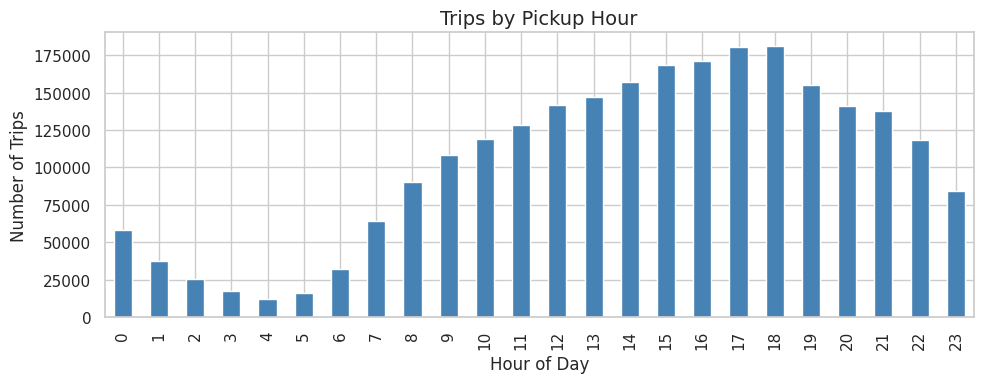

✓ Chart 1 saved


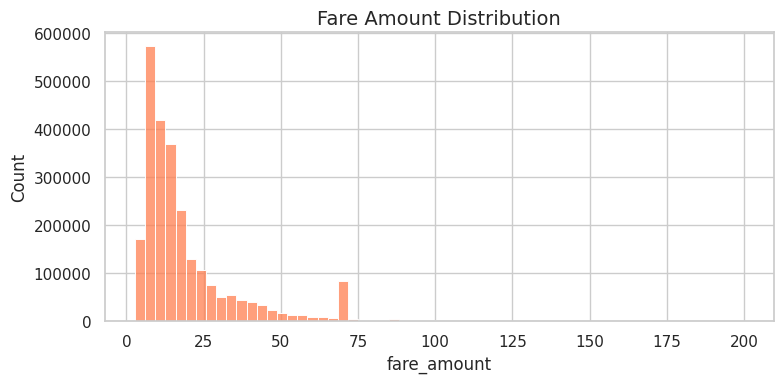

✓ Chart 2 saved


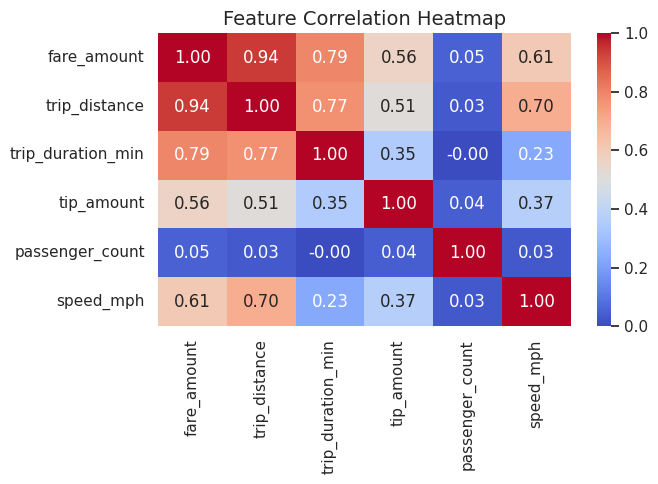

✓ Chart 3 saved


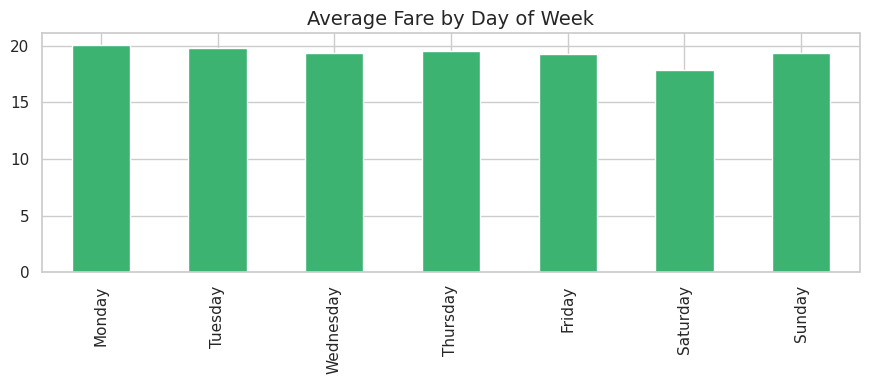

✓ Chart 4 saved


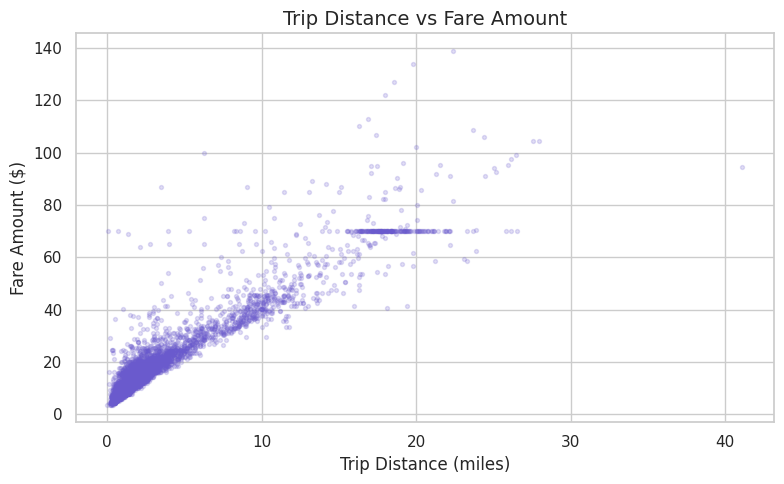

✓ Chart 5 saved


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../outputs/charts", exist_ok=True)
sns.set_theme(style="whitegrid")

# Chart 1: Trips by hour
fig, ax = plt.subplots(figsize=(10, 4))
df['pickup_hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Trips by Pickup Hour", fontsize=14)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("../outputs/charts/trips_by_hour.png", dpi=150)
plt.show()
print("✓ Chart 1 saved")

# Chart 2: Fare distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['fare_amount'], bins=60, ax=ax, color='coral', edgecolor='white')
ax.set_title("Fare Amount Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/fare_distribution.png", dpi=150)
plt.show()
print("✓ Chart 2 saved")

# Chart 3: Correlation heatmap
cols = ['fare_amount', 'trip_distance', 'trip_duration_min',
        'tip_amount', 'passenger_count', 'speed_mph']
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png", dpi=150)
plt.show()
print("✓ Chart 3 saved")

# Chart 4: Avg fare by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(9, 4))
df.groupby('pickup_day')['fare_amount'].mean().reindex(day_order).plot(
    kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title("Average Fare by Day of Week", fontsize=14)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../outputs/charts/fare_by_day.png", dpi=150)
plt.show()
print("✓ Chart 4 saved")

# Chart 5: Trip distance vs fare (sample)
fig, ax = plt.subplots(figsize=(8, 5))
sample = df.sample(5000, random_state=42)
ax.scatter(sample['trip_distance'], sample['fare_amount'], alpha=0.2, color='slateblue', s=8)
ax.set_title("Trip Distance vs Fare Amount", fontsize=14)
ax.set_xlabel("Trip Distance (miles)")
ax.set_ylabel("Fare Amount ($)")
plt.tight_layout()
plt.savefig("../outputs/charts/distance_vs_fare.png", dpi=150)
plt.show()
print("✓ Chart 5 saved")

In [9]:
df.to_csv("../outputs/cleaned_data.csv", index=False)
print("✓ Saved cleaned_data.csv")
print(f"  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Saved cleaned_data.csv
  Final shape: 2,493,003 rows × 26 columns


Linear Regression
  MAE : $2.16
  R²  : 0.9058

Training Random Forest... (takes ~1-2 min)
Random Forest
  MAE : $0.94
  R²  : 0.9787


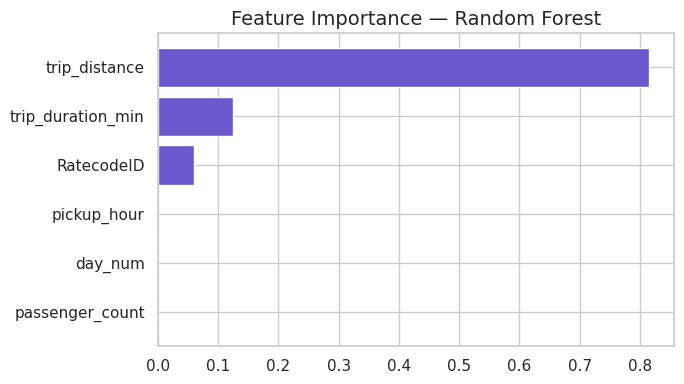

✓ Feature importance chart saved


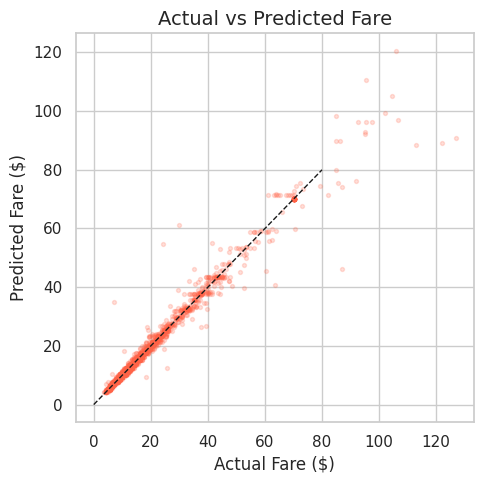

✓ Actual vs Predicted chart saved


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['trip_distance', 'trip_duration_min', 'passenger_count',
            'pickup_hour', 'day_num', 'RatecodeID']
target = 'fare_amount'

ml_df = df[features + [target]].dropna()
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression")
print(f"  MAE : ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"  R²  : {r2_score(y_test, y_pred_lr):.4f}")

# Random Forest
print("\nTraining Random Forest... (takes ~1-2 min)")
rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest")
print(f"  MAE : ${mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"  R²  : {r2_score(y_test, y_pred_rf):.4f}")

# Feature importance plot
imp = pd.DataFrame({'feature': features, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp['feature'], imp['importance'], color='slateblue')
ax.set_title("Feature Importance — Random Forest", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/feature_importance.png", dpi=150)
plt.show()
print("✓ Feature importance chart saved")

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test[:2000], y_pred_rf[:2000], alpha=0.2, color='tomato', s=8)
ax.plot([0, 80], [0, 80], 'k--', lw=1)
ax.set_xlabel("Actual Fare ($)")
ax.set_ylabel("Predicted Fare ($)")
ax.set_title("Actual vs Predicted Fare", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/charts/actual_vs_predicted.png", dpi=150)
plt.show()
print("✓ Actual vs Predicted chart saved")

In [11]:
import os

print("=== SQL Results ===")
for f in os.listdir("../outputs/sql_results"):
    print(f" ✓ {f}")

print("\n=== Charts ===")
for f in os.listdir("../outputs/charts"):
    print(f" ✓ {f}")

print("\n=== Cleaned Data ===")
size = os.path.getsize("../outputs/cleaned_data.csv") / (1024*1024)
print(f" ✓ cleaned_data.csv — {size:.1f} MB")

=== SQL Results ===
 ✓ tip_buckets.csv
 ✓ trips_by_day.csv
 ✓ trip_categories.csv
 ✓ busiest_hours.csv
 ✓ passenger_vs_tip.csv
 ✓ avg_speed_by_vendor.csv
 ✓ revenue_by_payment.csv

=== Charts ===
 ✓ fare_by_day.png
 ✓ fare_distribution.png
 ✓ trips_by_hour.png
 ✓ actual_vs_predicted.png
 ✓ distance_vs_fare.png
 ✓ correlation_heatmap.png
 ✓ feature_importance.png

=== Cleaned Data ===
 ✓ cleaned_data.csv — 405.2 MB
